# 🌸 Digital Addiction: What Really Drives a Social-Media Addiction Score?

**Course:** Python for Data Science (DSBA), 2025/2026 — final project
**Dataset:** Social-media usage & digital addiction (10,000 users, 23 fields)

> **Authors:** _Anya & Eva_ — please put your full names and group here before submitting.

---

## Abstract

Short-form video and endless feeds are often blamed for ruining our sleep and hijacking our
attention. This project uses a dataset of **10,000 social-media users** to ask a simple question:
**what actually drives a person's *addiction score*** — the time they spend on TikTok and Instagram,
their night-time scrolling, their age, or their sleep? We run a full analysis pipeline: we describe
the data and its quality, compute descriptive statistics, confirm the data is clean, engineer new
behavioural features, visualise the variables, and finally state and **statistically test three
hypotheses** with `scipy`.

The headline result is that **behaviour beats demographics**: daily time on social media is by far
the strongest correlate of addiction (and TikTok matters more than Instagram), while age and sleep
duration turn out to be unrelated to the addiction score — debunking a popular assumption.
**Contribution:** Anya — data loading, cleaning, descriptive statistics; Eva — visualisations,
hypothesis testing and write-up _(adjust this split to match how you actually divided the work)_.

## 1. Setup & styling

We use the standard data stack plus `scipy.stats` for the hypothesis tests, and a soft
**pink-beige pastel** theme for all figures.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cycler import cycler
from scipy import stats

# ── pastel pink / beige palette ──
PASTEL = {"blush": "#E7A6B0", "rose": "#D98AA0", "mauve": "#C98BAE",
          "plum": "#9B6A8F", "beige": "#E4D2B8", "taupe": "#CBB293",
          "cream": "#FBF3EC", "ink": "#6E4B5E"}
pastel_seq = ["#E7A6B0", "#D98AA0", "#C98BAE", "#E4D2B8", "#CBB293", "#9B6A8F"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=pastel_seq),
    "figure.facecolor": PASTEL["cream"], "axes.facecolor": PASTEL["cream"],
    "savefig.facecolor": PASTEL["cream"], "axes.edgecolor": PASTEL["taupe"],
    "axes.titlecolor": PASTEL["ink"], "axes.labelcolor": PASTEL["ink"],
    "xtick.color": PASTEL["ink"], "ytick.color": PASTEL["ink"],
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "grid.color": "#EAD9CC", "figure.dpi": 110,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.3


## 2. Dataset description

**Domain:** digital well-being / social-media behaviour. Each row is one user, described by their
daily usage of TikTok and Instagram, several behavioural indices (night usage, scroll velocity,
dopamine dependency, attention span, impulsivity), sleep, demographics (age, country, year) and a
final **`addiction_score`** plus a categorical **`addiction_level`** (Low / Medium / High / Severe).

In [2]:
df = pd.read_csv("data/data.csv")
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 10,000   Columns: 23


,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,instagram_minutes_daily,night_usage_ratio,scroll_velocity,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
0,1,Philippines,59,2050,88.90,64.35,0.31,0.31,64.76,242.85,27.40,0.26,2.61,69.98,77.48,27.02,60.04,6.56,7.91,100.00,40.46,63.51,High
1,2,Netherlands,23,2035,57.95,76.26,0.46,0.29,37.59,98.60,155.17,0.96,4.15,56.86,78.85,25.38,81.77,9.40,2.29,100.00,79.42,62.69,High
2,3,Laos,26,2060,40.33,55.85,0.89,0.18,22.59,127.22,69.90,0.96,2.79,41.82,83.57,19.71,99.61,7.81,2.31,100.00,88.26,59.86,High
3,4,Bulgaria,50,2046,43.84,28.39,0.66,0.16,57.09,140.53,58.22,0.69,3.95,70.81,83.44,19.87,86.94,7.02,4.51,100.00,70.91,59.94,High
4,5,Zambia,24,2045,43.75,81.41,0.28,0.46,57.65,187.75,148.33,0.72,2.43,71.99,71.99,33.61,45.28,7.90,4.27,100.00,51.31,66.80,High


### Data dictionary (key fields)

| Field | Meaning |
|-------|---------|
| `user_id` | unique user id (identifier, not a feature) |
| `country`, `age`, `year` | demographics / context |
| `tiktok_minutes_daily`, `instagram_minutes_daily` | minutes per day on each app |
| `night_usage_ratio` | share of usage happening at night (0–1) |
| `scroll_velocity` | how fast the user scrolls |
| `attention_span_score` | attention span (higher = better) |
| `dopamine_dependency_score` | dopamine-loop dependency |
| `impulsivity_index` | impulsivity |
| `sleep_hours`, `sleep_quality_index` | sleep duration & quality |
| `addiction_pressure`, `ASI`, `MHRI` | composite pressure / risk indices |
| `addiction_score` | **target: numeric addiction score (≈ 4–75)** |
| `addiction_level` | **target (categorical): Low / Medium / High / Severe** |

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      10000 non-null  int64  
 1   country                      10000 non-null  str    
 2   age                          10000 non-null  int64  
 3   year                         10000 non-null  int64  
 4   internet_penetration         10000 non-null  float64
 5   mental_health_support_index  10000 non-null  float64
 6   gdp_index                    10000 non-null  float64
 7   youth_population_ratio       10000 non-null  float64
 8   baseline_addiction_pressure  10000 non-null  float64
 9   tiktok_minutes_daily         10000 non-null  float64
 10  instagram_minutes_daily      10000 non-null  float64
 11  night_usage_ratio            10000 non-null  float64
 12  scroll_velocity              10000 non-null  float64
 13  addiction_pressure          

### Data quality

We check the three usual problems: missing values, duplicates, and inconsistent types / ranges.

In [4]:
print("Missing values total:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print()
print("addiction_level categories:", df["addiction_level"].unique().tolist())
print("year range:", df["year"].min(), "→", df["year"].max(), "(synthetic, includes future years)")
print("age range:", df["age"].min(), "→", df["age"].max())
print()
# ASI looks capped near 100 — worth noting
print("ASI quartiles:", df["ASI"].quantile([0.25, 0.5, 0.75]).round(1).tolist(),
      "→ heavily capped at 100")

Missing values total: 0
Duplicate rows: 0

addiction_level categories: ['High', 'Medium', 'Low', 'Severe']
year range: 2015 → 2060 (synthetic, includes future years)
age range: 13 → 59

ASI quartiles: [100.0, 100.0, 100.0] → heavily capped at 100


**Quality verdict.** The dataset is **clean**: no missing values and no duplicate rows. Types are
correct (numeric fields are numeric, `addiction_level`/`country` are categorical text). Two quirks
worth noting: `year` is synthetic and runs to 2060, and `ASI` is mostly capped at 100. Because the
data is already clean, the cleanup section is short, and we add new feature columns instead
(see §5).

## 3. Descriptive statistics

Summary statistics for the main numeric fields. For each we report **mean**, **median** and
**standard deviation**, plus the range and quartiles.

In [5]:
num_fields = ["tiktok_minutes_daily", "instagram_minutes_daily", "sleep_hours",
              "addiction_score", "night_usage_ratio", "attention_span_score"]
desc = df[num_fields].describe().T
desc["median"] = df[num_fields].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "75%", "max"]]
desc.round(2)

,count,mean,median,std,min,25%,75%,max
tiktok_minutes_daily,"10,000.00",120.92,120.42,58.32,0.00,79.61,161.26,356.31
instagram_minutes_daily,"10,000.00",100.11,99.61,49.32,0.00,66.10,133.42,277.10
sleep_hours,"10,000.00",7.00,6.99,1.46,3.00,5.99,8.04,10.00
addiction_score,"10,000.00",58.55,61.00,9.27,4.14,57.96,63.68,75.14
night_usage_ratio,"10,000.00",0.50,0.50,0.29,0.00,0.26,0.75,1.00
attention_span_score,"10,000.00",81.58,81.67,6.42,58.11,77.19,86.04,100.00


In [6]:
print("Key statistics (mean / median / std):\n")
for c in num_fields:
    s = df[c]
    print(f"{c:26} | mean = {s.mean():8.2f} | median = {s.median():8.2f} | std = {s.std():8.2f}")

Key statistics (mean / median / std):

tiktok_minutes_daily       | mean =   120.92 | median =   120.42 | std =    58.32
instagram_minutes_daily    | mean =   100.11 | median =    99.61 | std =    49.32
sleep_hours                | mean =     7.00 | median =     6.99 | std =     1.46
addiction_score            | mean =    58.55 | median =    61.00 | std =     9.27
night_usage_ratio          | mean =     0.50 | median =     0.50 | std =     0.29
attention_span_score       | mean =    81.58 | median =    81.67 | std =     6.42


**Reading the numbers.** Users spend on average ~121 min/day on TikTok and ~100 min/day on
Instagram (TikTok is used more). Sleep is centred at ~7 h with a symmetric spread. The
`addiction_score` averages ~58 with a fairly tight spread, and `night_usage_ratio` is uniformly
spread between 0 and 1.

## 4. Data cleanup

The data is already clean, so here we *demonstrate* that it is clean, fix the categorical type of
`addiction_level`, and drop the `user_id` identifier (not an analytical feature). We work on a copy.

In [7]:
data = df.copy()

# make addiction_level an ordered category (Low < Medium < High < Severe)
level_order = ["Low", "Medium", "High", "Severe"]
data["addiction_level"] = pd.Categorical(data["addiction_level"],
                                         categories=level_order, ordered=True)

# user_id is an identifier, not a feature
data = data.drop(columns=["user_id"])

print("NaNs after cleanup:", int(data.isna().sum().sum()))
print("Duplicates after cleanup:", int(data.duplicated().sum()))
print("addiction_level is ordered:", data["addiction_level"].cat.ordered)
print("Shape:", data.shape)

NaNs after cleanup: 0
Duplicates after cleanup: 0
addiction_level is ordered: True
Shape: (10000, 22)


**Cleanup result.** Confirmed: 0 missing values, 0 duplicates, correct types. `addiction_level`
is now an ordered category we can sort meaningfully, and the identifier column is removed.

## 5. Feature engineering (new columns)

Because the data needed no real cleanup, we add several new behavioural features derived from the
existing columns:

- **`total_minutes`** = `tiktok_minutes_daily` + `instagram_minutes_daily`
- **`daily_hours`** = `total_minutes` / 60
- **`tiktok_share`** = `tiktok_minutes_daily` / `total_minutes` (how TikTok-dominated a user is)
- **`night_minutes`** = `total_minutes` × `night_usage_ratio` (minutes spent scrolling at night)
- **`age_group`** = age binned into `<25` / `25–35` / `35+`
- **`heavy_user`** = 1 if total time is above the median, else 0
- **`level_num`** = ordinal encoding of `addiction_level` (Low=1 … Severe=4)

In [8]:
data["total_minutes"] = data["tiktok_minutes_daily"] + data["instagram_minutes_daily"]
data["daily_hours"]   = data["total_minutes"] / 60
data["tiktok_share"]  = data["tiktok_minutes_daily"] / data["total_minutes"].replace(0, np.nan)
data["night_minutes"] = data["total_minutes"] * data["night_usage_ratio"]
data["age_group"]     = pd.cut(data["age"], bins=[0, 25, 35, 200],
                               labels=["<25", "25-35", "35+"])
data["heavy_user"]    = (data["total_minutes"] > data["total_minutes"].median()).astype(int)
data["level_num"]     = data["addiction_level"].cat.codes + 1     # Low=1 … Severe=4

data[["tiktok_minutes_daily", "instagram_minutes_daily", "total_minutes", "daily_hours",
      "tiktok_share", "night_minutes", "age_group", "heavy_user", "level_num"]].head()

,tiktok_minutes_daily,instagram_minutes_daily,total_minutes,daily_hours,tiktok_share,night_minutes,age_group,heavy_user,level_num
0,242.85,27.40,270.25,4.50,0.90,70.52,35+,1,3
1,98.60,155.17,253.77,4.23,0.39,244.50,<25,1,3
2,127.22,69.90,197.12,3.29,0.65,189.52,25-35,0,3
3,140.53,58.22,198.75,3.31,0.71,136.33,35+,0,3
4,187.75,148.33,336.08,5.60,0.56,240.92,<25,1,3


In [9]:
data[["total_minutes", "daily_hours", "tiktok_share", "night_minutes"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
total_minutes,"10,000.00",221.03,76.99,0.00,167.54,219.94,273.68,502.74
daily_hours,"10,000.00",3.68,1.28,0.00,2.79,3.67,4.56,8.38
tiktok_share,"9,995.00",0.54,0.20,0.00,0.43,0.55,0.67,1.00
night_minutes,"10,000.00",111.33,77.53,0.00,48.30,98.89,162.18,444.26


**Discussion.** The typical user spends ~3.7 h/day on the two apps combined, split fairly evenly
between TikTok and Instagram, and a meaningful chunk of that happens at night. These engineered
features let us compare *heavy* vs *light* users and TikTok-dominant vs Instagram-dominant users in
the analysis below.

## 6. Single-variable plots (5 numeric fields, 3 plot types)

We look at the shape of five numeric fields — `tiktok_minutes_daily`, `instagram_minutes_daily`,
`addiction_score`, `sleep_hours`, `total_minutes` — using **histograms**, a **box plot** and a
**scatter plot**.

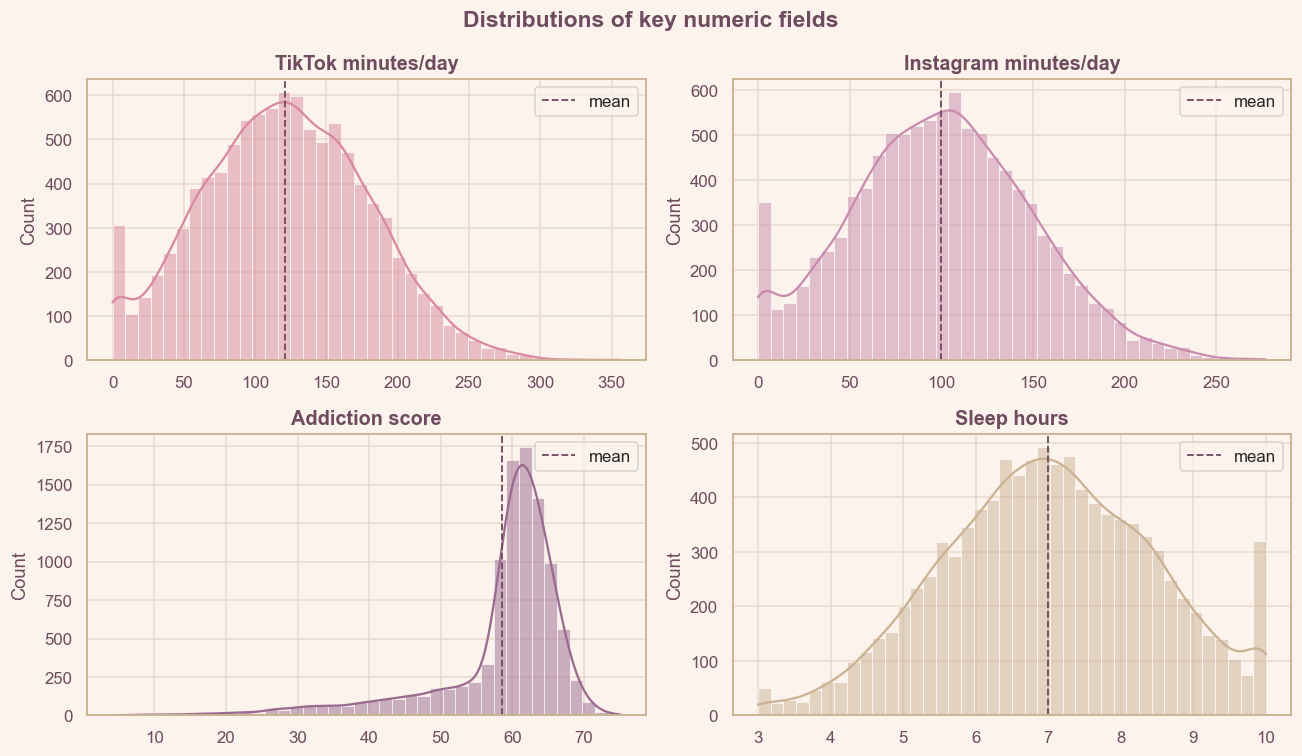

In [10]:
# Type 1 — HISTOGRAMS
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
specs = [("tiktok_minutes_daily", "TikTok minutes/day", "#D98AA0"),
         ("instagram_minutes_daily", "Instagram minutes/day", "#C98BAE"),
         ("addiction_score", "Addiction score", "#9B6A8F"),
         ("sleep_hours", "Sleep hours", "#CBB293")]
for ax, (col, title, color) in zip(axes.flat, specs):
    sns.histplot(data[col], bins=40, kde=True, color=color, ax=ax,
                 edgecolor="white", linewidth=0.4)
    ax.axvline(data[col].mean(), color=PASTEL["ink"], ls="--", lw=1.2, label="mean")
    ax.set_title(title); ax.set_xlabel(""); ax.legend()
fig.suptitle("Distributions of key numeric fields", color=PASTEL["ink"],
             fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

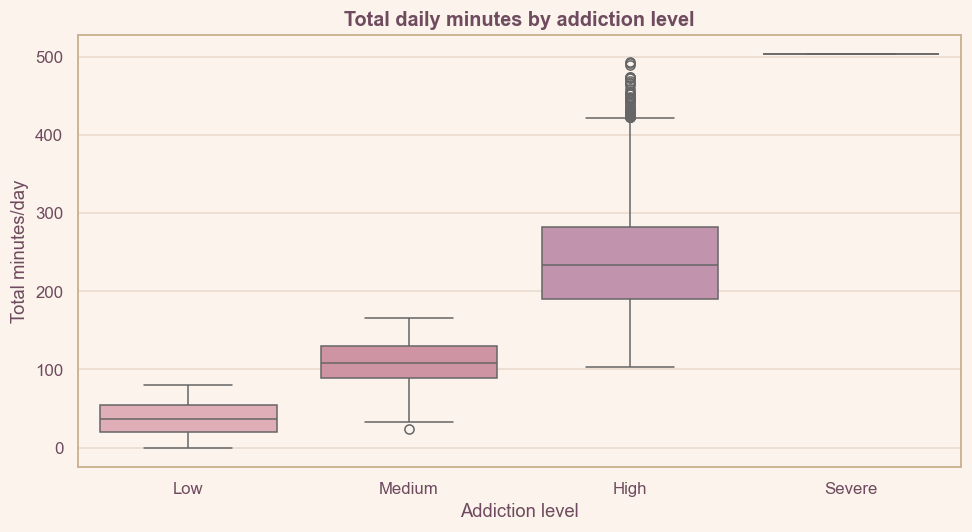

In [11]:
# Type 2 — BOX PLOT: total minutes across addiction levels
plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="addiction_level", y="total_minutes",
            order=["Low", "Medium", "High", "Severe"], palette=pastel_seq)
plt.title("Total daily minutes by addiction level")
plt.xlabel("Addiction level"); plt.ylabel("Total minutes/day")
plt.tight_layout(); plt.show()

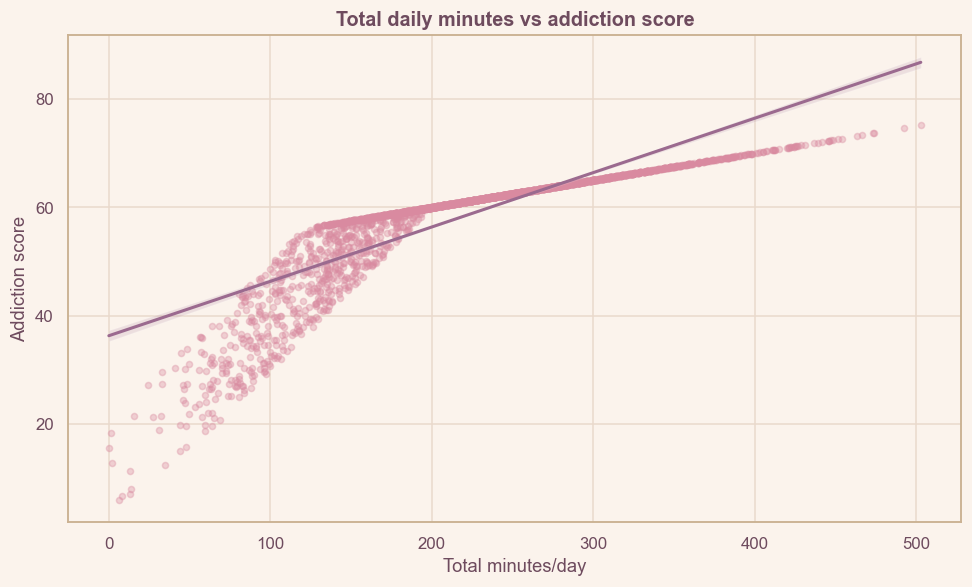

In [12]:
# Type 3 — SCATTER + regression: total minutes vs addiction score
sample = data.sample(3000, random_state=1)
plt.figure(figsize=(9, 5.5))
sns.regplot(data=sample, x="total_minutes", y="addiction_score",
            scatter_kws=dict(alpha=0.35, s=16, color=PASTEL["rose"]),
            line_kws=dict(color=PASTEL["plum"], lw=2))
plt.title("Total daily minutes vs addiction score")
plt.xlabel("Total minutes/day"); plt.ylabel("Addiction score")
plt.tight_layout(); plt.show()

**Discussion.** TikTok and Instagram minutes are roughly bell-shaped (TikTok shifted higher), the
addiction score is concentrated around 55–65, and sleep is symmetric around 7 h. The box plot shows
total minutes rising sharply with addiction level, and the scatter shows a clear upward
minutes → addiction trend. Five numeric fields covered with three plot types.

## 7. Detailed comparisons & relationships

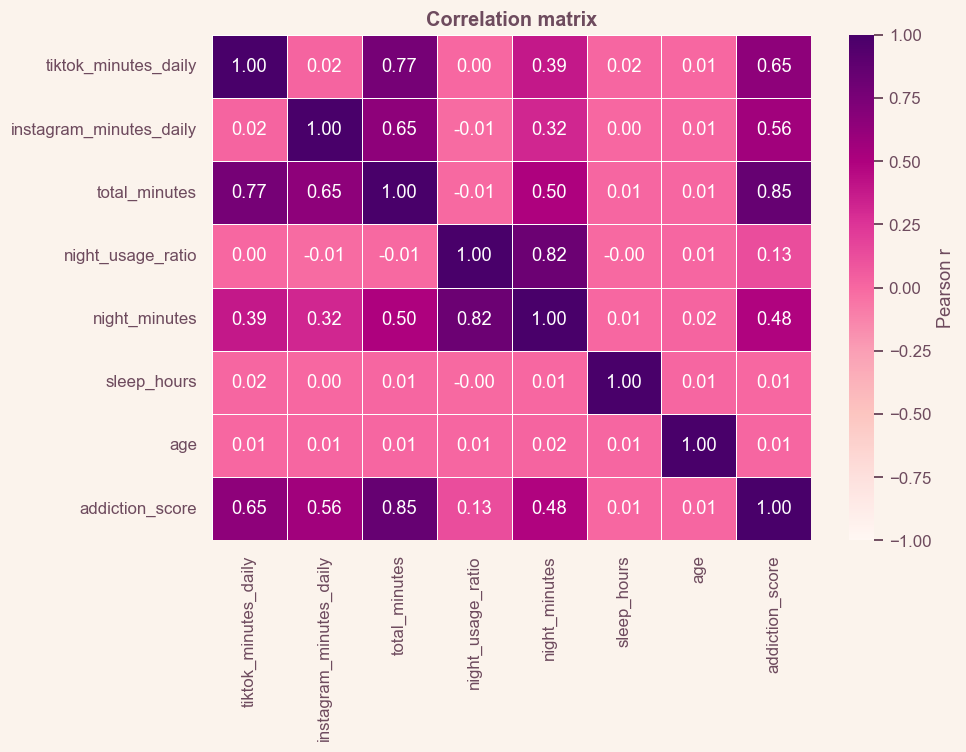

In [13]:
# 7.1 Correlation heatmap of behavioural numeric fields
corr_cols = ["tiktok_minutes_daily", "instagram_minutes_daily", "total_minutes",
             "night_usage_ratio", "night_minutes", "sleep_hours", "age", "addiction_score"]
plt.figure(figsize=(9, 7))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdPu",
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Pearson r"})
plt.title("Correlation matrix")
plt.tight_layout(); plt.show()

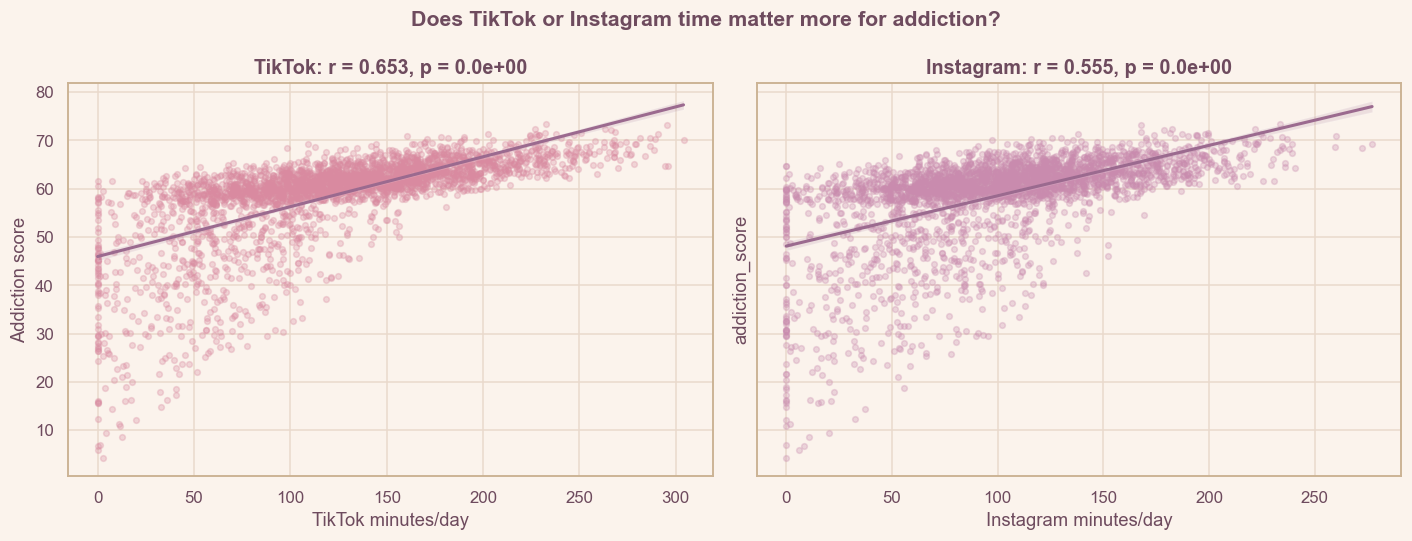

In [14]:
# 7.2 TikTok vs Instagram: effect on addiction, side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, col, title, color in zip(
        axes, ["tiktok_minutes_daily", "instagram_minutes_daily"],
        ["TikTok", "Instagram"], [PASTEL["rose"], PASTEL["mauve"]]):
    s = data.sample(3000, random_state=2)
    sns.regplot(data=s, x=col, y="addiction_score", ax=ax,
                scatter_kws=dict(alpha=0.3, s=14, color=color),
                line_kws=dict(color=PASTEL["plum"], lw=2))
    r, p = stats.pearsonr(data[col], data["addiction_score"])
    ax.set_title(f"{title}: r = {r:.3f}, p = {p:.1e}")
    ax.set_xlabel(f"{title} minutes/day")
axes[0].set_ylabel("Addiction score")
fig.suptitle("Does TikTok or Instagram time matter more for addiction?",
             color=PASTEL["ink"], fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

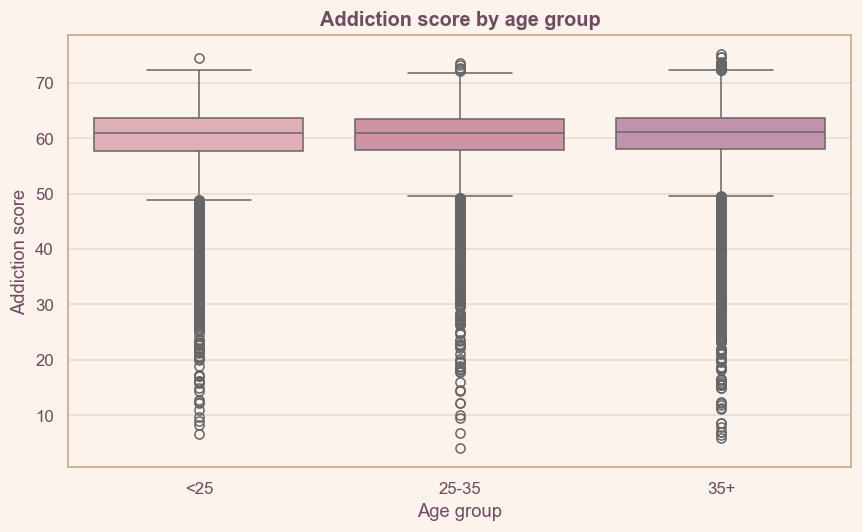

Mean addiction score by age group:
 age_group
<25     58.38
25-35   58.45
35+     58.68


In [15]:
# 7.3 Addiction score by age group (is age related at all?)
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x="age_group", y="addiction_score",
            order=["<25", "25-35", "35+"], palette=pastel_seq)
means = data.groupby("age_group", observed=True)["addiction_score"].mean()
plt.title("Addiction score by age group")
plt.xlabel("Age group"); plt.ylabel("Addiction score")
plt.tight_layout(); plt.show()
print("Mean addiction score by age group:\n", means.round(2).to_string())

In [16]:
# 7.4 Behavioural profile by addiction level (printed subset statistics)
profile = data.groupby("addiction_level", observed=True).agg(
    n=("addiction_level", "size"),
    total_minutes=("total_minutes", "mean"),
    night_minutes=("night_minutes", "mean"),
    sleep_hours=("sleep_hours", "mean"),
    age=("age", "mean"),
).round(1)
profile

,n,total_minutes,night_minutes,sleep_hours,age
addiction_level,,,,,
Low,121,37.60,9.30,7.30,34.00
Medium,1198,108.60,39.00,6.90,35.70
High,8680,239.10,122.70,7.00,35.80
Severe,1,502.70,395.00,7.20,37.00


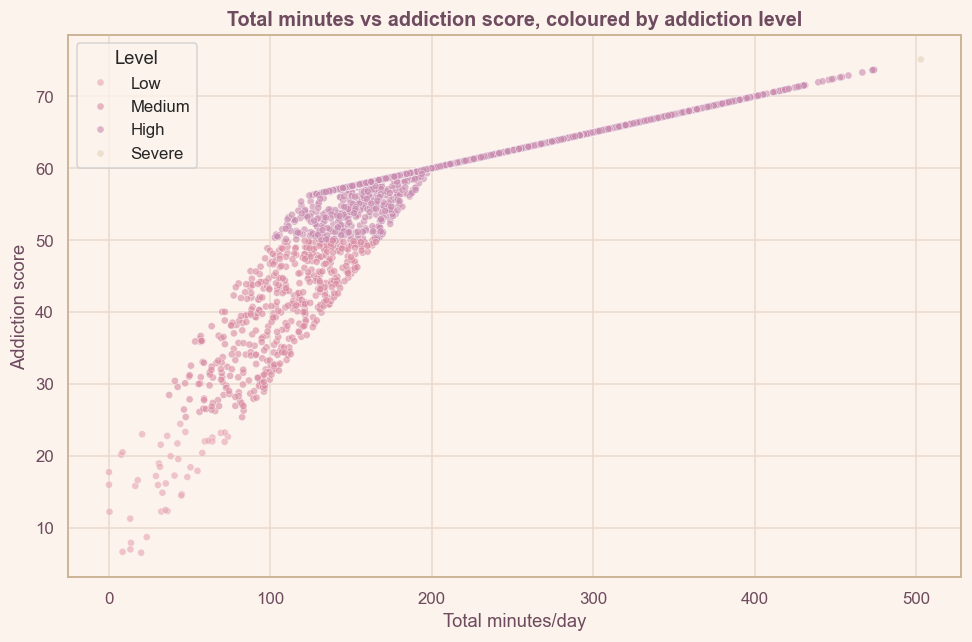

In [17]:
# 7.5 Three variables at once: minutes vs addiction, coloured by addiction level
s = data.sample(4000, random_state=3)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=s, x="total_minutes", y="addiction_score",
                hue="addiction_level", hue_order=["Low", "Medium", "High", "Severe"],
                palette=pastel_seq[:4], alpha=0.6, s=22)
plt.title("Total minutes vs addiction score, coloured by addiction level")
plt.xlabel("Total minutes/day"); plt.ylabel("Addiction score")
plt.legend(title="Level")
plt.tight_layout(); plt.show()

**Discussion.** The correlation matrix makes the story obvious: `addiction_score` is strongly tied
to total minutes (and to TikTok/Instagram minutes), while `sleep_hours` and `age` sit near zero —
they are essentially **uncorrelated** with addiction. TikTok's correlation (~0.65) is higher than
Instagram's (~0.56). Age groups have practically identical addiction scores, and the behavioural
profile table shows that higher addiction levels are defined by far more daily and night-time
minutes — not by sleep or age.

## 8. Hypothesis testing

We state three hypotheses and test each with a figure **and** a statistical test
(`scipy.stats`), at significance level α = 0.05.

### Hypothesis 1 — Time drives addiction, and TikTok matters more than Instagram

**Claim:** daily time on social media is positively associated with the addiction score, and
**TikTok contributes more than Instagram**. We test the two correlations and then fit a
standardised linear regression so the two apps' contributions are directly comparable.

In [18]:
r_tt, p_tt = stats.pearsonr(data["tiktok_minutes_daily"], data["addiction_score"])
r_ig, p_ig = stats.pearsonr(data["instagram_minutes_daily"], data["addiction_score"])
r_tot, p_tot = stats.pearsonr(data["total_minutes"], data["addiction_score"])
print(f"TikTok    vs addiction: r = {r_tt:.3f} (p = {p_tt:.1e})")
print(f"Instagram vs addiction: r = {r_ig:.3f} (p = {p_ig:.1e})")
print(f"Total     vs addiction: r = {r_tot:.3f} (p = {p_tot:.1e})")

# standardised regression: addiction ~ z(tiktok) + z(instagram)
z = lambda x: (x - x.mean()) / x.std()
X = np.column_stack([np.ones(len(data)), z(data["tiktok_minutes_daily"]),
                     z(data["instagram_minutes_daily"])])
beta, *_ = np.linalg.lstsq(X, z(data["addiction_score"]).values, rcond=None)
print(f"\nStandardised coefficients (β):  TikTok = {beta[1]:.3f}   Instagram = {beta[2]:.3f}")
print("TikTok effect is stronger than Instagram:", bool(beta[1] > beta[2]))

TikTok    vs addiction: r = 0.653 (p = 0.0e+00)
Instagram vs addiction: r = 0.555 (p = 0.0e+00)
Total     vs addiction: r = 0.850 (p = 0.0e+00)

Standardised coefficients (β):  TikTok = 0.644   Instagram = 0.545
TikTok effect is stronger than Instagram: True


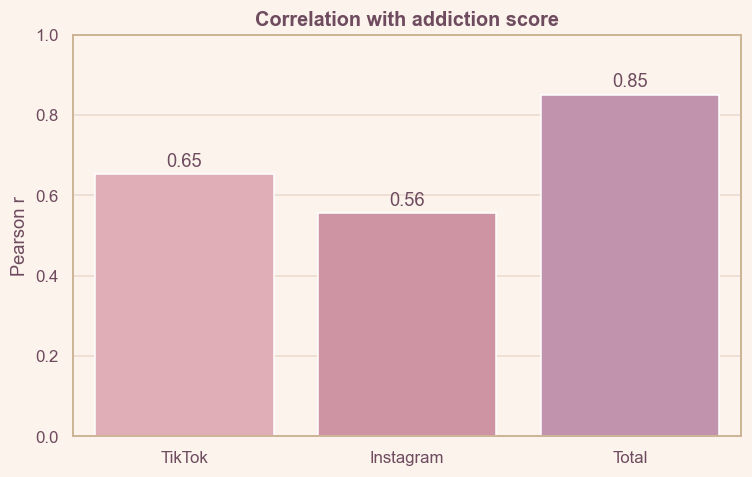

In [19]:
plt.figure(figsize=(7, 4.5))
sns.barplot(x=["TikTok", "Instagram", "Total"], y=[r_tt, r_ig, r_tot], palette=pastel_seq)
plt.title("Correlation with addiction score")
plt.ylabel("Pearson r"); plt.ylim(0, 1)
for i, v in enumerate([r_tt, r_ig, r_tot]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", color=PASTEL["ink"])
plt.tight_layout(); plt.show()

**Verdict on H1 — confirmed.** Both apps' minutes are strongly and significantly correlated with the
addiction score (p ≪ 0.05), the combined time even more so (r ≈ 0.85). The standardised regression
gives TikTok a larger coefficient than Instagram, so **TikTok contributes more** — exactly as
claimed.

### Hypothesis 2 — Heavy users are more addicted than light users, in every age group

**Claim:** users above the median in total daily time (*heavy users*) have a higher addiction score
than light users — and this holds **within each age group**, i.e. behaviour matters regardless of
age. We compare heavy vs light users inside each age group with Welch's t-test.

In [20]:
rows = []
for g, sub in data.groupby("age_group", observed=True):
    heavy = sub[sub["heavy_user"] == 1]["addiction_score"]
    light = sub[sub["heavy_user"] == 0]["addiction_score"]
    t, p = stats.ttest_ind(heavy, light, equal_var=False)
    rows.append([g, round(light.mean(), 1), round(heavy.mean(), 1),
                 round(heavy.mean() - light.mean(), 1), p])
h2 = pd.DataFrame(rows, columns=["age_group", "light_mean", "heavy_mean",
                                 "gap", "p_value"])
print(h2.to_string(index=False))
print("\nHeavy users score higher in every age group:", bool((h2["gap"] > 0).all()))
print("Significant (p<0.05) in every age group:", bool((h2["p_value"] < 0.05).all()))

age_group  light_mean  heavy_mean   gap  p_value
      <25       52.70       64.20 11.40     0.00
    25-35       53.00       64.10 11.00     0.00
      35+       53.00       64.20 11.20     0.00

Heavy users score higher in every age group: True
Significant (p<0.05) in every age group: True


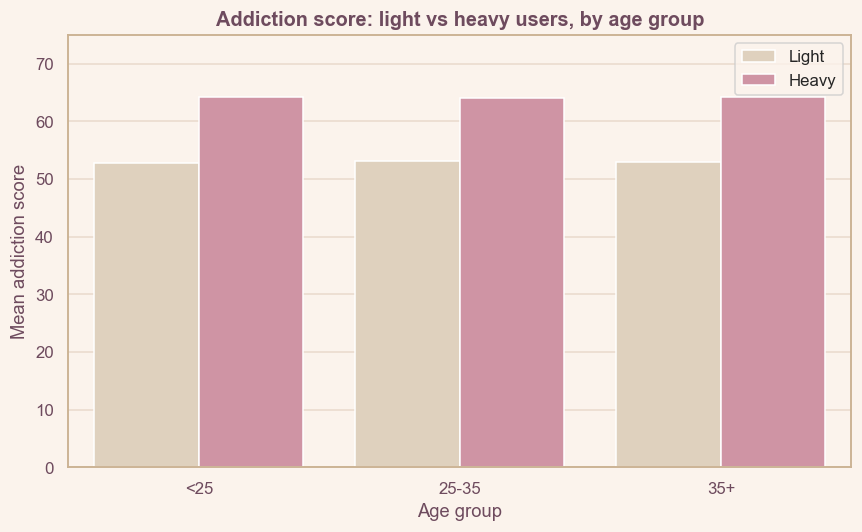

In [21]:
plot_df = data.groupby(["age_group", "heavy_user"], observed=True)["addiction_score"].mean().reset_index()
plot_df["user"] = plot_df["heavy_user"].map({0: "Light", 1: "Heavy"})
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="age_group", y="addiction_score", hue="user",
            order=["<25", "25-35", "35+"], palette=[PASTEL["beige"], PASTEL["rose"]])
plt.title("Addiction score: light vs heavy users, by age group")
plt.xlabel("Age group"); plt.ylabel("Mean addiction score"); plt.legend(title="")
plt.ylim(0, 75)
plt.tight_layout(); plt.show()

**Verdict on H2 — confirmed.** In every age group heavy users score markedly higher than light
users (a ~11-point gap), and the difference is highly significant (p ≪ 0.05) in all groups. Usage
behaviour predicts addiction consistently across ages — supporting the idea that **behaviour beats
demographics**.

### Hypothesis 3 — Neither age nor sleep duration is related to addiction

This directly challenges a common assumption (and our earlier intuition) that young people or
poor sleepers are more addicted. **Claim:** once we look at the data, **age and sleep are *not*
associated with the addiction score**. We test both correlations and compare the youngest (<25) vs
oldest (35+) users with a t-test.

In [22]:
r_age, p_age = stats.pearsonr(data["age"], data["addiction_score"])
r_sleep, p_sleep = stats.pearsonr(data["sleep_hours"], data["addiction_score"])
young = data[data["age"] < 25]["addiction_score"]
adult = data[data["age"] >= 35]["addiction_score"]
t, p_grp = stats.ttest_ind(young, adult, equal_var=False)

print(f"age   vs addiction: r = {r_age:+.3f} (p = {p_age:.3f})")
print(f"sleep vs addiction: r = {r_sleep:+.3f} (p = {p_sleep:.3f})")
print(f"\nMean addiction — young (<25): {young.mean():.2f}, adults (35+): {adult.mean():.2f}")
print(f"t-test young vs adult: t = {t:.2f}, p = {p_grp:.3f}")
print("\nAge correlation negligible & non-significant:", bool(p_age > 0.05))
print("Sleep correlation negligible & non-significant:", bool(p_sleep > 0.05))

age   vs addiction: r = +0.010 (p = 0.295)
sleep vs addiction: r = +0.007 (p = 0.498)

Mean addiction — young (<25): 58.38, adults (35+): 58.67
t-test young vs adult: t = -1.30, p = 0.194

Age correlation negligible & non-significant: True
Sleep correlation negligible & non-significant: True


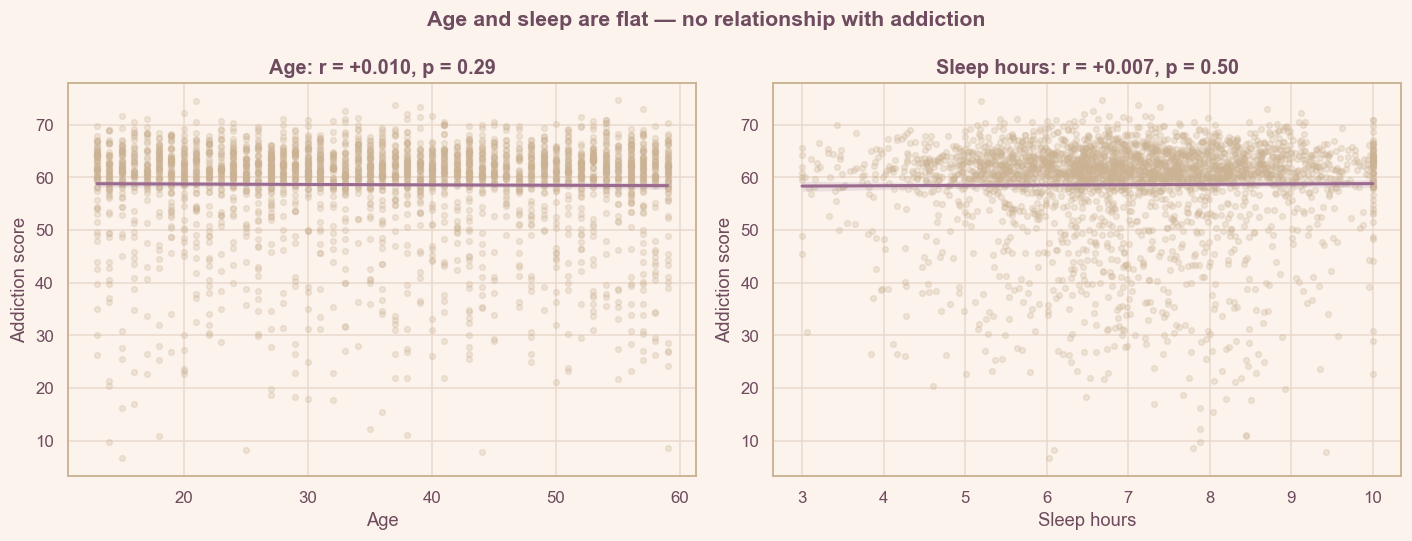

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
s = data.sample(3000, random_state=4)
for ax, col, title in zip(axes, ["age", "sleep_hours"], ["Age", "Sleep hours"]):
    sns.regplot(data=s, x=col, y="addiction_score", ax=ax,
                scatter_kws=dict(alpha=0.25, s=14, color=PASTEL["taupe"]),
                line_kws=dict(color=PASTEL["plum"], lw=2))
    r, p = stats.pearsonr(data[col], data["addiction_score"])
    ax.set_title(f"{title}: r = {r:+.3f}, p = {p:.2f}")
    ax.set_xlabel(title); ax.set_ylabel("Addiction score")
fig.suptitle("Age and sleep are flat — no relationship with addiction",
             color=PASTEL["ink"], fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

**Verdict on H3 — confirmed (a null result).** Both correlations are essentially zero and not
significant (|r| ≈ 0.01, p ≫ 0.05), and the young-vs-adult difference is not significant. So in this
dataset **age and sleep duration do not explain addiction** — the popular "young people / bad
sleepers are more addicted" story does not hold here.

## 9. Conclusions

1. **Time on social media is the dominant driver of the addiction score** (total minutes r ≈ 0.85).
2. **TikTok matters more than Instagram** (H1): higher correlation and a larger standardised
   regression coefficient.
3. **Behaviour beats demographics** (H2): heavy users are more addicted than light users in *every*
   age group, significantly.
4. **Age and sleep are unrelated to addiction** (H3): a clean null result that debunks a common
   assumption.
5. The behavioural indices that move with addiction are usage-based (minutes, night-time scrolling),
   while sleep, age, country and GDP play no measurable role here.

**Takeaway.** If you want to predict or reduce a person's digital-addiction score in this data, look
at **how much** (and how late) they scroll — especially on TikTok — not at how old they are or how
long they sleep. The analysis used pandas, matplotlib/seaborn and scipy hypothesis tests.